<a href="https://colab.research.google.com/github/KeerthanaSistla/Sem6DeepLearning/blob/main/DeepLearningSem6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction

Features of Deep Learning
*   Requires More amount of data
*   DL deals with non linear-data
*   Images, videos, audio and text
*   Complex model (hard to interpret)
*   Requires Graphical and Tenser Processing Units
*   Takes large computation
*   Automatic feature extractuion

PyTourch
*   Implimented  using LUA

TensorFlow
*   Implimented using C++, CUDA or Python

Keras
*   Implimented using Python

#Basic Coding

In [ ]:
import tensorflow as tf


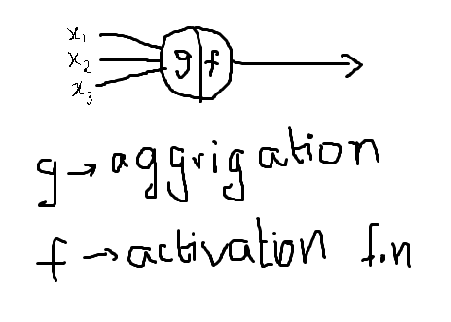

**g (aggrigation)** adds i.e., x1 + x2 + x3

**f (activation)** checks with condition
*   Step f.n, Sigmoid f.n, etc.
*   Fired if output is tangable

**Weights**
*   Priority of each input
*   g = x1w1 + x2w2 + x3w3

**Bias**
*   Adds non-linearity
*   Acts as a decision boundry

#Week 2

In [ ]:
import numpy as np

def step(x):
  return 1 if x >= 0 else 0

class Perceptron:
  def __init__(self, weights, bias):
    self.weights = weights
    self.bias = bias

  def predict(self, inputs):
              z = np.dot(self.weights, inputs)+self.bias
              return step(z)

#AND Operation
weights = np.array([1, 1])
bias = -1.5

and_gate = Perceptron(weights, bias)

print("AND Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", and_gate.predict(np.array(x)))

#OR Operation
weights = np.array([1, 1])
bias = -0.5

or_gate = Perceptron(weights, bias)

print("OR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", or_gate.predict(np.array(x)))

AND Gate
(0, 0) -> 0
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1
OR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1


In [ ]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class XOR_network:
    def __init__(self):
        self.w_or = np.array([1, 1])
        self.b_or = -0.5

        self.w_and = np.array([1, 1])
        self.b_and = -1.5

        self.w_out = np.array([1, -2])
        self.b_out = -0.5

    def predict(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)
        h2 = step(np.dot(self.w_and, x) + self.b_and)
        output = step(np.dot(self.w_out, [h1, h2]) + self.b_out)
        return output

xor = XOR_network()

print("XOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xor.predict(np.array(x)))

XOR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0


In [ ]:
# ~XOR Function

import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class XOR_network:
    def __init__(self):
        self.w_or = np.array([1, 1])
        self.b_or = -0.5

        self.w_and = np.array([1, 1])
        self.b_and = -1.5

        self.w_out = np.array([1, -2])
        self.b_out = -0.5

    def predict(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)
        h2 = step(np.dot(self.w_and, x) + self.b_and)
        return step(np.dot(self.w_out, [h1, h2]) + self.b_out)

class XNOR_network(XOR_network):
    def predict(self, x):
        return 1 - super().predict(x)

xnor = XNOR_network()

print("XNOR Gate")
for x in [(0,0),(0,1),(1,0),(1,1)]:
    print(x, "->", xnor.predict(np.array(x)))

XNOR Gate
(0, 0) -> 1
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


In [ ]:
# Harsh Threshold
import numpy as np

def step(x):
  return 1 if x >= 0 else 0

class Neuron:
  def __init__(self, weights, bias):
    self.weights = weights
    self.bias = bias
  def feedforward(self, inputs):
    total = np.dot(self.weights, inputs) + self.bias
    return step(total)

weights = np.array([0, 1])
b_1 = -3.1
b_2 = 2
b_3 = -3.0

n = Neuron(weights, b_1)
n_2 = Neuron(weights, b_2)
n_3 = Neuron(weights,b_3)

x = np.array([2, 3])

print("with bias -3.1:",n.feedforward(x))
print("\nwith bias -3.0:",n_3.feedforward(x))
print("\nwith bias 2:",n_2.feedforward(x))

with bias -3.1: 0

with bias -3.0: 1

with bias 2: 1


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("movies.csv")

X = data[['f1', 'f2', 'f3', 'f4']].values
y = data['label'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

learning_rate = 0.01
epochs = 50
weights = np.zeros(X.shape[1])
bias = 0.0

def step_function(z):
    return 1 if z >= 0 else 0

for epoch in range(epochs):
    total_errors = 0

    indices = np.random.permutation(len(X))

    for i in indices:
        linear_output = np.dot(X[i], weights) + bias
        y_pred = step_function(linear_output)

        error = y[i] - y_pred

        if error != 0:
            weights += learning_rate * error * X[i]
            bias += learning_rate * error
            total_errors += 1

    print(
        f"Epoch {epoch+1:02d} | "
        f"Errors: {total_errors} | "
        f"Weights: {weights.round(3)} | "
        f"Bias: {round(bias, 3)}"
    )

    if total_errors == 0:
        print("\nConverged")
        break

print("\nFinal Weights:", weights)
print("Final Bias:", bias)

Epoch 01 | Errors: 4 | Weights: [0.    0.    0.    0.028] | Bias: 0.0
Epoch 02 | Errors: 2 | Weights: [ 0.     0.    -0.02   0.032] | Bias: 0.0
Epoch 03 | Errors: 2 | Weights: [ 0.     0.    -0.     0.048] | Bias: 0.0
Epoch 04 | Errors: 1 | Weights: [ 0.01  -0.01  -0.008  0.047] | Bias: 0.01
Epoch 05 | Errors: 0 | Weights: [ 0.01  -0.01  -0.008  0.047] | Bias: 0.01

Converged

Final Weights: [ 0.01       -0.01       -0.00816497  0.04699912]
Final Bias: 0.01


In [ ]:
import itertools
import numpy as np

class Perceptron:
    def __init__(self, lr=0.1, epochs=100):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0

        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                output = self.predict(xi)
                update = self.lr * (target - output)
                if update != 0:
                    self.w += update * xi
                    self.b += update
                    errors += 1
            if errors == 0:
                return True   # converged
        return False          # did not converge

    def predict(self, x):
        return 1 if np.dot(x, self.w) + self.b >= 0 else 0

def generate_boolean_functions(n):
    inputs = np.array(list(itertools.product([0, 1], repeat=n)))
    functions = list(itertools.product([0, 1], repeat=2**n))
    return inputs, functions

def test_perceptron(n):
    X, functions = generate_boolean_functions(n)
    perceptron = Perceptron()
    not_learnable = 0

    for f in functions:
        y = np.array(f)
        learned = perceptron.fit(X, y)
        if not learned:
            not_learnable += 1

    total = len(functions)
    print(f"Inputs: {n}")
    print(f"Total Boolean functions: {total}")
    print(f"Not learnable by perceptron: {not_learnable}")
    print(f"Learnable: {total - not_learnable}\n")

def theoretical_results(n):
    known = {
        4: (65536, 1882),
        5: (2**32, 94572)
    }

    if n in known:
        total, linear = known[n]
        print(f"Inputs: {n}")
        print(f"Total Boolean functions: {total}")
        print(f"Learnable (linearly separable): {linear}")
        print(f"Not learnable: {total - linear}\n")
    else:
        print(f"Inputs: {n}")
        print("Total Boolean functions grow as 2^(2^n)")
        print("Almost all Boolean functions are non-linearly separable\n")

if __name__ == "__main__":

    # Brute-force (safe)
    test_perceptron(2)
    test_perceptron(3)

    # Theory-based (avoids infinite runtime)
    for n in range(4, 6):
        theoretical_results(n)

Inputs: 2
Total Boolean functions: 16
Not learnable by perceptron: 2
Learnable: 14

Inputs: 3
Total Boolean functions: 256
Not learnable by perceptron: 152
Learnable: 104

Inputs: 4
Total Boolean functions: 65536
Learnable (linearly separable): 1882
Not learnable: 63654

Inputs: 5
Total Boolean functions: 4294967296
Learnable (linearly separable): 94572
Not learnable: 4294872724



In [ ]:
# How many Boolean functions can be designed using three binary inputs?
import itertools
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

X = np.array(list(itertools.product([0, 1], repeat=3)))

boolean_functions = list(itertools.product([0, 1], repeat=8))


class BooleanMLP:
    def __init__(self):
        self.hidden_weights = []
        self.hidden_biases = []

        for pattern in X:
            w = np.array([1 if bit == 1 else -1 for bit in pattern])
            b = -sum(pattern) + 0.5
            self.hidden_weights.append(w)
            self.hidden_biases.append(b)

    def forward(self, x, output_weights):
        hidden_outputs = []
        for w, b in zip(self.hidden_weights, self.hidden_biases):
            hidden_outputs.append(step(np.dot(w, x) + b))

        return step(np.dot(output_weights, hidden_outputs) - 0.5)

mlp = BooleanMLP()
successful = 0

for f in boolean_functions:
    output_weights = np.array(f)
    correct = True

    for x, target in zip(X, f):
        y = mlp.forward(x, output_weights)
        if y != target:
            correct = False
            break

    if correct:
        successful += 1

print(f"Total Boolean functions: {len(boolean_functions)}")
print(f"Functions perfectly represented: {successful}")

Total Boolean functions: 256
Functions perfectly represented: 256


#Week 3

Simple MLP (Binary Classification Example)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simple dataset (XOR-like)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_deriv(x):
    return x*(1-x)

def train_mlp(lr, epochs=2000):
    np.random.seed(0)

    # Initialize weights and bias
    W1 = np.random.randn(2,4)
    b1 = np.zeros((1,4))
    W2 = np.random.randn(4,1)
    b2 = np.zeros((1,1))

    losses = []

    for _ in range(epochs):
        # Forward
        z1 = X @ W1 + b1
        a1 = sigmoid(z1)
        z2 = a1 @ W2 + b2
        y_hat = sigmoid(z2)

        loss = np.mean((y - y_hat)**2)
        losses.append(loss)

        # Backprop
        d2 = (y_hat - y) * sigmoid_deriv(y_hat)
        d1 = d2 @ W2.T * sigmoid_deriv(a1)

        # Update
        W2 -= lr * a1.T @ d2
        b2 -= lr * np.sum(d2, axis=0, keepdims=True)
        W1 -= lr * X.T @ d1
        b1 -= lr * np.sum(d1, axis=0, keepdims=True)

    return losses[-1]

Varying Learning Rate

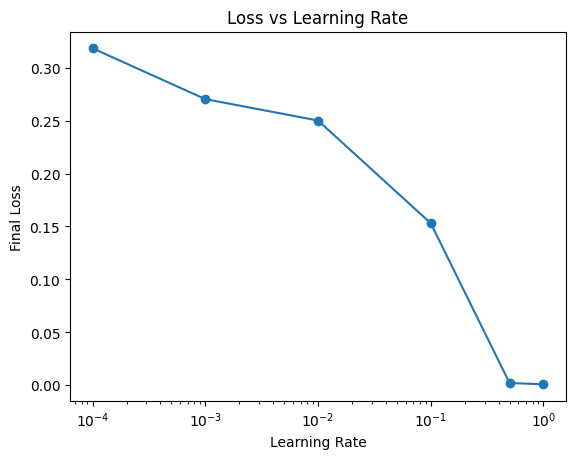

In [ ]:
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5, 1]
final_losses = []

for lr in learning_rates:
    loss = train_mlp(lr)
    final_losses.append(loss)

plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Loss vs Learning Rate")
plt.xscale("log")
plt.show()

Batch Gradient Descent (BGD)

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    learning_rate_init=0.01,
    max_iter=500,
    solver='sgd',
    batch_size=200,
    momentum=0.0,
    random_state=1,
    verbose=True
)

mlp.fit(X, y.ravel())

Iteration 1, loss = 0.74578547
Iteration 2, loss = 0.74518115
Iteration 3, loss = 0.74458467
Iteration 4, loss = 0.74399592
Iteration 5, loss = 0.74341480
Iteration 6, loss = 0.74284121
Iteration 7, loss = 0.74227505
Iteration 8, loss = 0.74171620
Iteration 9, loss = 0.74116458
Iteration 10, loss = 0.74062008
Iteration 11, loss = 0.74008260
Iteration 12, loss = 0.73955205
Iteration 13, loss = 0.73902833
Iteration 14, loss = 0.73851134
Iteration 15, loss = 0.73800101
Iteration 16, loss = 0.73749722
Iteration 17, loss = 0.73699990
Iteration 18, loss = 0.73650894
Iteration 19, loss = 0.73602427
Iteration 20, loss = 0.73555019
Iteration 21, loss = 0.73511371
Iteration 22, loss = 0.73468329
Iteration 23, loss = 0.73425883
Iteration 24, loss = 0.73384024
Iteration 25, loss = 0.73342745
Iteration 26, loss = 0.73302037
Iteration 27, loss = 0.73261892
Iteration 28, loss = 0.73222301
Iteration 29, loss = 0.73183256
Iteration 30, loss = 0.73144750
Iteration 31, loss = 0.73106775
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:609: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


MLPClassifier(batch_size=200, hidden_layer_sizes=(10,), learning_rate_init=0.01,
              max_iter=500, momentum=0.0, random_state=1, solver='sgd',
              verbose=True)

Perceptron Implementation

In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

for lr in [0.0001, 0.001, 0.01, 0.1, 1]:
    clf = Perceptron(
        eta0=lr,
        max_iter=1000,
        tol=1e-3,
        penalty=None,
        random_state=42
    )
    clf.fit(X_train, y_train)
    print("LR:", lr, "Accuracy:", clf.score(X_test, y_test))

LR: 0.0001 Accuracy: 0.8888888888888888
LR: 0.001 Accuracy: 0.8888888888888888
LR: 0.01 Accuracy: 0.8888888888888888
LR: 0.1 Accuracy: 0.8888888888888888
LR: 1 Accuracy: 0.8888888888888888


MLP on MNIST

In [ ]:
import tensorflow
from tensorflow.keras.datasets import mnist
from tensorflow.keras import models, layers

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=15, batch_size=64)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8776 - loss: 0.4257
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9725 - loss: 0.0935
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9828 - loss: 0.0557
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9870 - loss: 0.0403
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9912 - loss: 0.0288
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9925 - loss: 0.0225
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9933 - loss: 0.0194
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9951 - loss: 0.0165
Epoch 9/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9943 - loss: 0.0166
Epoch 10/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9958 - loss: 0.0128
Epoch 11/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9952 - loss: 0.0155
Epoch 12/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/ste

Optimal Architecture

In [ ]:
model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=15, batch_size=64)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8559 - loss: 0.4626
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9588 - loss: 0.1332
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9727 - loss: 0.0892
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9761 - loss: 0.0729
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9801 - loss: 0.0632
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9827 - loss: 0.0563
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9850 - loss: 0.0469
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9845 - loss: 0.0449
Epoch 9/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9868 - loss: 0.0423
Epoch 10/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9867 - loss: 0.0401
Epoch 11/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9885 - loss: 0.0355
Epoch 12/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/ste

#Week 4

In [ ]:
#USING OPTIMIZATION ALGO
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import altair as alt

y = np.array([[0, 1, 1, 0]]).T

X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

model = Sequential()
model.add(Dense(16, input_dim=2, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='mean_squared_error',
              optimizer='adam',
              metrics=['binary_accuracy', 'mean_squared_error'])

history = model.fit(X, y, epochs=1000, verbose=0)

errors = history.history['loss']

df2 = pd.DataFrame({"errors":errors, "time-step": np.arange(0, len(errors))})

alt.Chart(df2).mark_line().encode(x="time-step", y="errors").properties(title='Chart 3')

y_pred = model.predict(X).round()
num_correct_predictions = (y_pred == y).sum()
accuracy = (num_correct_predictions / y.shape[0]) * 100
print('Multi-layer perceptron accuracy: %.2f%%' % accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Multi-layer perceptron accuracy: 100.00%


In [ ]:
#USING SGD OPTIMIZATION ALGO
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import altair as alt

y = np.array([[0, 1, 1, 0]]).T

X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

model = Sequential()
model.add(Dense(16, input_dim=2, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='mean_squared_error',
              optimizer=SGD(),
              metrics=['binary_accuracy', 'mean_squared_error'])

history = model.fit(X, y, epochs=1000, verbose=0)

errors = history.history['loss']

df2 = pd.DataFrame({"errors":errors, "time-step": np.arange(0, len(errors))})

alt.Chart(df2).mark_line().encode(x="time-step", y="errors").properties(title='Chart 3')

y_pred = model.predict(X).round()
num_correct_predictions = (y_pred == y).sum()
accuracy = (num_correct_predictions / y.shape[0]) * 100
print('Multi-layer perceptron accuracy: %.2f%%' % accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Multi-layer perceptron accuracy: 50.00%


In [ ]:
# Using MGD (Momentum Gradient Descent) Optimizer
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import altair as alt
from tensorflow.keras.optimizers import SGD

# expected values
y = np.array([[0, 1, 1, 0]]).T

# features
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

model_mgd = Sequential()
model_mgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_mgd.add(Dense(1, activation='sigmoid'))

model_mgd.compile(loss='mean_squared_error',
                  optimizer=SGD(momentum=0.1),
                  metrics=['binary_accuracy', 'mean_squared_error'])

history_mgd = model_mgd.fit(X, y, epochs=1000, verbose=0)

errors_mgd = history_mgd.history['loss']

df_mgd = pd.DataFrame({"errors": errors_mgd, "time-step": np.arange(0, len(errors_mgd))})

alt.Chart(df_mgd).mark_line().encode(x="time-step", y="errors").properties(title='MGD Optimizer - Loss Curve')

y_pred_mgd = model_mgd.predict(X).round()
num_correct_predictions_mgd = (y_pred_mgd == y).sum()
accuracy_mgd = (num_correct_predictions_mgd / y.shape[0]) * 100
print('MGD Optimizer accuracy: %.2f%%' % accuracy_mgd)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
MGD Optimizer accuracy: 50.00%


In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
import altair as alt

# expected values
y = np.array([[0, 1, 1, 0]]).T

# features
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

model_mgd = Sequential()
model_mgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_mgd.add(Dense(1, activation='sigmoid'))

model_mgd.compile(
    loss='mean_squared_error',
    optimizer=SGD(momentum=0.1),
    metrics=['binary_accuracy', 'mean_squared_error']
)

# Early stopping callback
early_stop = EarlyStopping(
    monitor='loss',
    patience=20,
    restore_best_weights=True
)

history_mgd = model_mgd.fit(
    X,
    y,
    epochs=1000,
    callbacks=[early_stop],
    verbose=0
)

errors_mgd = history_mgd.history['loss']

df_mgd = pd.DataFrame({
    "errors": errors_mgd,
    "time-step": np.arange(len(errors_mgd))
})

alt.Chart(df_mgd).mark_line().encode(
    x="time-step",
    y="errors"
).properties(title='MGD Optimizer - Loss Curve (Early Stopping)')

# Evaluate
y_pred_mgd = model_mgd.predict(X).round()
num_correct_predictions_mgd = (y_pred_mgd == y).sum()
accuracy_mgd = (num_correct_predictions_mgd / y.shape[0]) * 100

print(f"MGD Optimizer accuracy: {accuracy_mgd:.2f}%")
print(f"Training stopped at epoch: {len(errors_mgd)}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
MGD Optimizer accuracy: 75.00%
Training stopped at epoch: 1000


In [ ]:
import numpy as np
import pandas as pd
import altair as alt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# expected values
y = np.array([[0, 1, 1, 0]]).T

# features
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

# 🔁 Learning rate schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.5,   # HIGH at start
    decay_steps=100,             # how fast it decays
    decay_rate=0.9,              # decay factor
    staircase=False              # smooth decay
)

optimizer = SGD(
    learning_rate=lr_schedule,
    momentum=0.1
)

model_mgd = Sequential()
model_mgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_mgd.add(Dense(1, activation='sigmoid'))

model_mgd.compile(
    loss='mean_squared_error',
    optimizer=optimizer,
    metrics=['binary_accuracy', 'mean_squared_error']
)

early_stop = EarlyStopping(
    monitor='loss',
    patience=20,
    restore_best_weights=True
)

history_mgd = model_mgd.fit(
    X,
    y,
    epochs=1000,
    callbacks=[early_stop],
    verbose=0
)

errors_mgd = history_mgd.history['loss']

df_mgd = pd.DataFrame({
    "errors": errors_mgd,
    "time-step": np.arange(len(errors_mgd))
})

alt.Chart(df_mgd).mark_line().encode(
    x="time-step",
    y="errors"
).properties(title='MGD Optimizer - Dynamic LR + Early Stopping')

# Evaluate
y_pred_mgd = model_mgd.predict(X).round()
accuracy_mgd = (y_pred_mgd == y).mean() * 100

print(f"MGD Optimizer accuracy: {accuracy_mgd:.2f}%")
print(f"Training stopped at epoch: {len(errors_mgd)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
MGD Optimizer accuracy: 50.00%
Training stopped at epoch: 1000


In [ ]:
import numpy as np
import pandas as pd
import altair as alt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler

def step_lr(epoch, lr):
    if epoch < 100:
        return 0.5
    elif epoch < 200:
        return 0.2
    elif epoch < 300:
        return 0.1
    elif epoch < 400:
        return 0.05
    else:
        return 0.01

# expected values (XOR)
y = np.array([[0, 1, 1, 0]]).T

# features
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

optimizer = SGD(momentum=0.9)

model_mgd = Sequential()
model_mgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_mgd.add(Dense(1, activation='sigmoid'))

model_mgd.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['binary_accuracy']
)

early_stop = EarlyStopping(
    monitor='loss',
    patience=50,
    restore_best_weights=True
)

lr_scheduler = LearningRateScheduler(step_lr)

history_mgd = model_mgd.fit(
    X,
    y,
    epochs=1000,
    callbacks=[lr_scheduler, early_stop],
    verbose=0
)

# Loss curve
errors_mgd = history_mgd.history['loss']

df_mgd = pd.DataFrame({
    "errors": errors_mgd,
    "time-step": np.arange(len(errors_mgd))
})

alt.Chart(df_mgd).mark_line().encode(
    x="time-step",
    y="errors"
).properties(title='MGD Optimizer – Step LR + Early Stopping')

# Evaluate
y_pred_mgd = model_mgd.predict(X).round()
accuracy_mgd = (y_pred_mgd == y).mean() * 100

print(f"MGD Optimizer accuracy: {accuracy_mgd:.2f}%")
print(f"Training stopped at epoch: {len(errors_mgd)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
MGD Optimizer accuracy: 100.00%
Training stopped at epoch: 1000


In [ ]:
import numpy as np
import pandas as pd
import altair as alt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# XOR data
y = np.array([[0, 1, 1, 0]]).T
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

lrs = [0.5, 0.1, 0.05, 0.01]
ms = [0.1, 0.3, 0.7, 0.9]

for lr in lrs:
    for m in ms:
        # Optimizer with current lr and momentum
        optimizer = SGD(learning_rate=lr, momentum=m)

        # Model
        model = Sequential()
        model.add(Dense(16, input_dim=2, activation='sigmoid'))
        model.add(Dense(1, activation='sigmoid'))

        model.compile(
            loss='binary_crossentropy',
            optimizer=optimizer,
            metrics=['binary_accuracy']
        )

        # Train
        history = model.fit(X, y, epochs=500, verbose=0)

        # Evaluate
        y_pred = model.predict(X).round()
        accuracy = (y_pred == y).mean() * 100

        print("Accuracy\tLearning Rate\tMomentum")
        print(f"{accuracy:.2f}\t\t{lr}\t\t{m}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
Accuracy	Learning Rate	Momentum
75.00		0.5		0.1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
Accuracy	Learning Rate	Momentum
75.00		0.5		0.3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Accuracy	Learning Rate	Momentum
100.00		0.5		0.7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Accuracy	Learning Rate	Momentum
100.00		0.5		0.9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Accuracy	Learning Rate	Momentum
50.00		0.1		0.1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
Accuracy	Learning Rate	Momentum
50.00		0.1		0.3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
Accuracy	Learning Rate	Momentum
50.00		0.1		0.7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Accuracy	Learning Rate	Momentum
100.00		0.1		0.9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Accuracy	Learning Rate	Momentum
50.00		0.05		0.1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Accuracy	Learning Rate	Momentum
50.00		0.05		0.3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
Accuracy	Learning Rate	Momentum
50.00		0.05		0.7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/ste

#Week 4

Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adadelta, Adam

Create XOR Dataset

In [ ]:
# XOR Data
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=np.float32)

y = np.array([[0],[1],[1],[0]], dtype=np.float32)

Define MLP Model

In [ ]:
def create_xor_model():
    model = Sequential([
        Dense(8, activation='tanh', input_shape=(2,)),
        Dense(1, activation='sigmoid')
    ])
    return model

Train & Record Results Function

In [ ]:
def train_optimizer(optimizer, name, batch_size):

    model = create_xor_model()

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X, y,
        epochs=500,
        batch_size=batch_size,
        verbose=0
    )

    losses = history.history['loss']

    y_pred = (model.predict(X) > 0.5).astype(int)
    accuracy = (y_pred == y).mean() * 100

    print(f"{name}")
    print("Accuracy: %.2f%%" % accuracy)
    print("Predictions:", y_pred.T)
    print("-"*40)

    return losses

Training

In [ ]:
results = {}

# Batch GD
results["BGD"] = train_optimizer(
    SGD(learning_rate=0.1),
    "Batch GD",
    batch_size=4
)

# Stochastic GD
results["SGD"] = train_optimizer(
    SGD(learning_rate=0.1),
    "Stochastic GD",
    batch_size=1
)

# Mini-Batch GD
results["MiniBatch"] = train_optimizer(
    SGD(learning_rate=0.1),
    "Mini Batch GD",
    batch_size=2
)

# Momentum
results["Momentum"] = train_optimizer(
    SGD(learning_rate=0.1, momentum=0.9),
    "SGD with Momentum",
    batch_size=1
)

# Nesterov
results["Nesterov"] = train_optimizer(
    SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
    "SGD with Nesterov",
    batch_size=1
)

# Adagrad
results["Adagrad"] = train_optimizer(
    Adagrad(learning_rate=0.5),
    "Adagrad",
    batch_size=1
)

# RMSprop
results["RMSprop"] = train_optimizer(
    RMSprop(learning_rate=0.01),
    "RMSprop",
    batch_size=1
)

# Adadelta
results["Adadelta"] = train_optimizer(
    Adadelta(),
    "Adadelta",
    batch_size=1
)

# Adam
results["Adam"] = train_optimizer(
    Adam(learning_rate=0.01),
    "Adam",
    batch_size=1
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Batch GD
Accuracy: 100.00%
Predictions: [[0 1 1 0]]
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Stochastic GD
Accuracy: 100.00%
Predictions: [[0 1 1 0]]
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Mini Batch GD
Accuracy: 100.00%
Predictions: [[0 1 1 0]]
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
SGD with Momentum
Accuracy: 100.00%
Predictions: [[0 1 1 0]]
----------------------------------------


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
SGD with Nesterov
Accuracy: 100.00%
Predictions: [[0 1 1 0]]
----------------------------------------


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
Adagrad
Accuracy: 100.00%
Predictions: [[0 1 1 0]]
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
RMSprop
Accuracy: 100.00%
Predictions: [[0 1 1 0]]
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
Adadelta
Accuracy: 25.00%
Predictions: [[1 0 0 0]]
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
Adam
Accuracy: 100.00%
Predictions: [[0 1 1 0]]
----------------------------------------


Plot Loss Curves

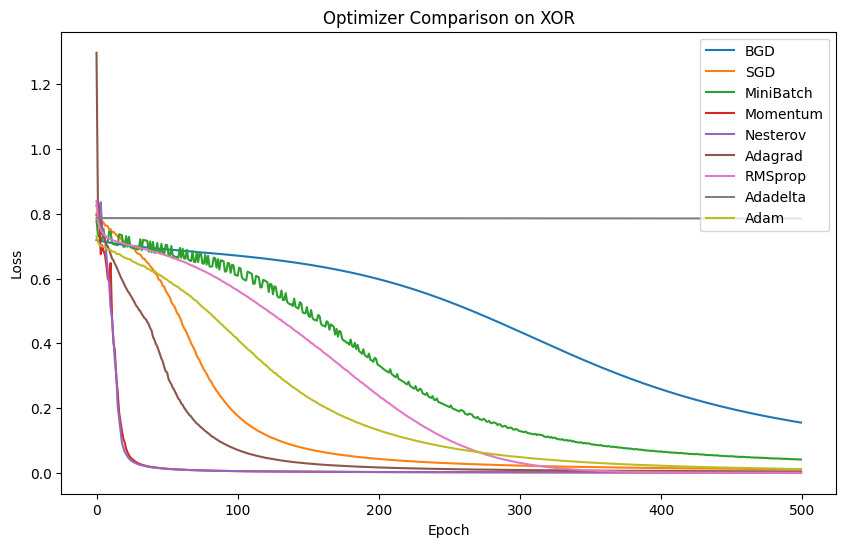

In [ ]:
plt.figure(figsize=(10,6))

for name, loss in results.items():
    plt.plot(loss, label=name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparison on XOR")
plt.legend()
plt.show()

#Week 5

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
422/422 - 12s - 29ms/step - accuracy: 0.7991 - loss: 1.0576 - val_accuracy: 0.8447 - val_loss: 0.7276
Epoch 2/50
422/422 - 2s - 6ms/step - accuracy: 0.8438 - loss: 0.6677 - val_accuracy: 0.8527 - val_loss: 0.5816
Epoch 3/50
422/422 - 1s - 3ms/step - accuracy: 0.8516 - loss: 0.5685 - val_accuracy: 0.8618 - val_loss: 0.5243
Epoch 4/50
422/422 - 1s - 3ms/step - accuracy: 0.8552 - loss: 0.5262 - val_accuracy: 0.8697 - val_loss: 0.4905
Epoch 5/50
422/422 - 1s - 3ms/step - accuracy: 0.8581 - loss: 0.5101 - val_accuracy: 0.8648 - val_loss: 0.4912
Epoch 6/50
422/422 - 2s - 4ms/step - accuracy: 0.8630 - loss: 0.4863 - val_accuracy: 0.8628 - val_loss: 0.4774
Epoch 7/50
422/422 - 1s - 3ms/step - accuracy: 0.8623 - loss: 0.4824 - val_accuracy: 0.8612 - val_loss: 0.4818
Epoch 8/50
422/422 - 1s - 3ms/step - accuracy: 0.8648 - loss: 0.4763 - val_accuracy: 0.8643 - val_loss: 0.4695
Epoch 9/50
422/422 - 1s - 3ms/step - accuracy: 0.8642 - loss: 0.4710 - val_accuracy: 0.8665 - val_loss: 0.4698

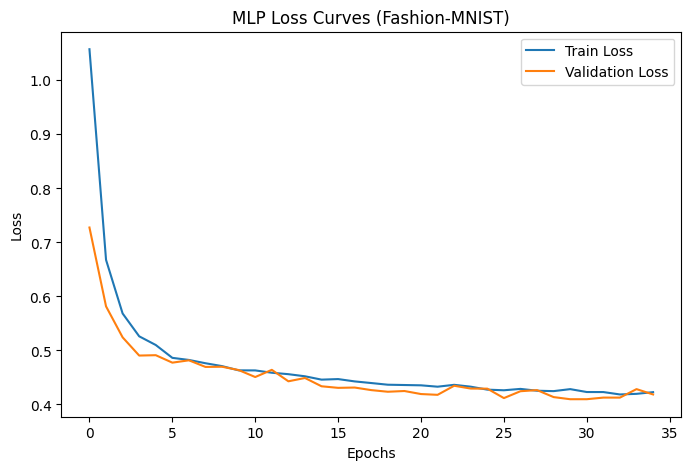

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# =========================
# Load Fashion-MNIST
# =========================
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train = X_train.reshape(-1, 28*28) / 255.0
X_test = X_test.reshape(-1, 28*28) / 255.0

# =========================
# Early stopping
# =========================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# =========================
# Create MLP model
# =========================
def create_mlp_model(dropout_rate=0.0, l2=0.0):
    model = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(28*28,),
                     kernel_regularizer=regularizers.l2(l2)),
        layers.Dropout(dropout_rate),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2)),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# =========================
# Train model with L2 + Dropout
# =========================
model = create_mlp_model(dropout_rate=0.2, l2=0.001)
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=128,
    callbacks=[early_stop],
    verbose=2
)

# =========================
# Evaluate
# =========================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", test_acc)

# =========================
# Plot loss curves
# =========================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MLP Loss Curves (Fashion-MNIST)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Training set: (48000, 784)
Validation set: (12000, 784)
Test set: (10000, 784)

Original training samples: 1000
Augmented training samples: 4000

1. TRAINING WITH DATA AUGMENTATION
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6992 - loss: 0.8829 - val_accuracy: 0.7681 - val_loss: 0.6991
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8090 - loss: 0.5383 - val_accuracy: 0.7832 - val_loss: 0.6626
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8555 - loss: 0.4139 - val_accuracy: 0.8037 - val_loss: 0.5982
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8700 - loss: 0.3598 - val_accuracy: 0.8013 - val_loss: 0.6234
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8955 - loss: 0.2953 - val_accuracy: 0.7854 - val_loss: 0.6847
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9020 - loss: 0.2644 - val_accuracy: 0.8035 - val_loss: 0.6538
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/st

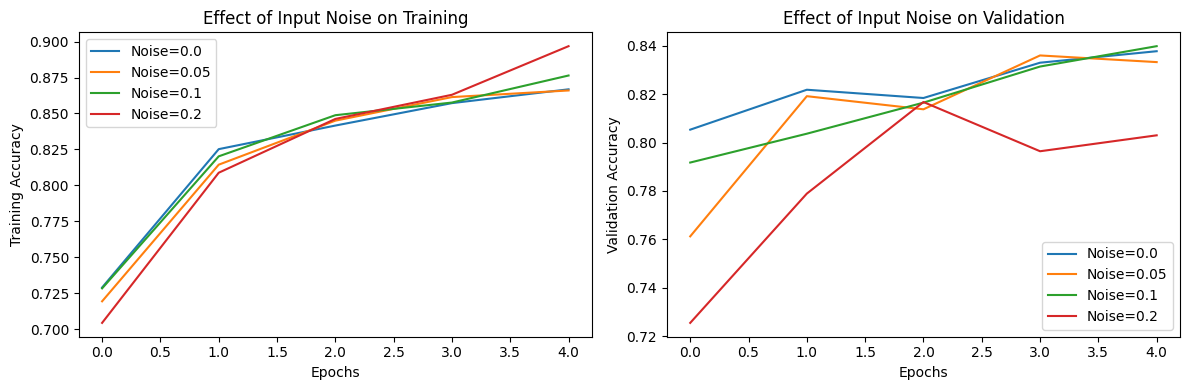


4. ENSEMBLE METHODS

Training model 1/5

Training model 2/5

Training model 3/5

Training model 4/5

Training model 5/5

Ensemble accuracy: 0.8489
Model 1 accuracy: 0.8327
Model 2 accuracy: 0.8195
Model 3 accuracy: 0.8442
Model 4 accuracy: 0.8365
Model 5 accuracy: 0.8297

5. REGULARIZATION TECHNIQUES COMPARISON

Training with none...

Training with l2_0.001...

Training with dropout_0.3...

Training with noise_0.1...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


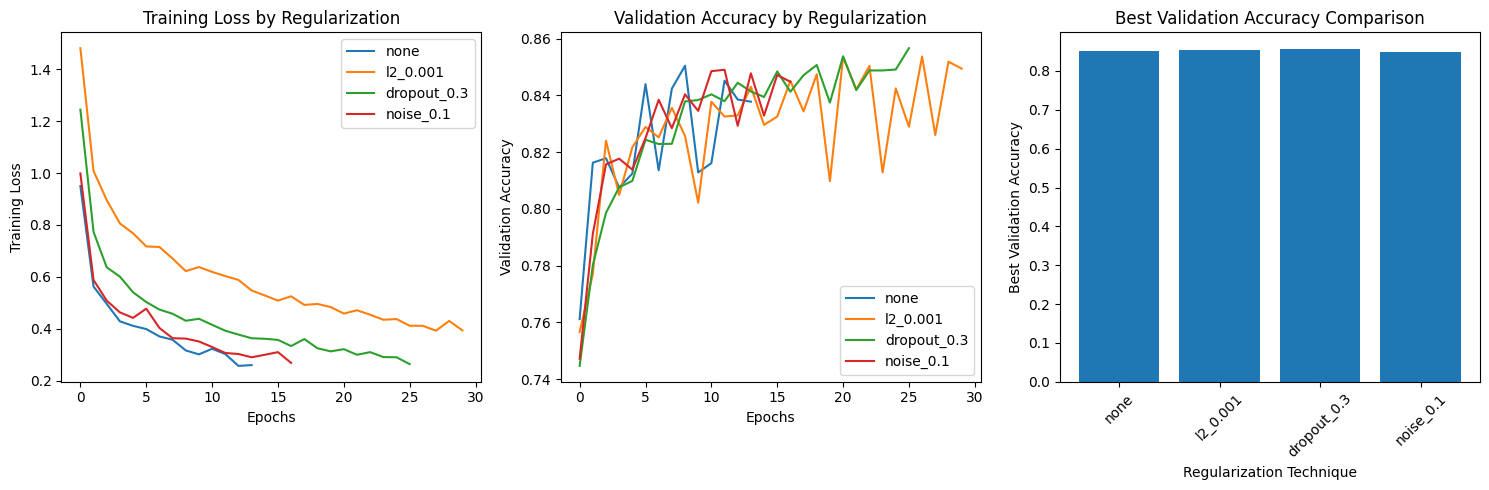


OBSERVATIONS AND ANALYSIS

1. Data Augmentation: Increased training data diversity, helped generalize better
2. Parameter Sharing: Reduced model parameters significantly (showing efficiency)
3. Input/Output Noise: Acts as a regularizer, preventing overfitting
4. Ensemble Methods: Improved accuracy through model averaging
5. Dropout: Most effective for preventing co-adaptation of neurons
6. L2 Regularization: Good for weight decay and simpler models
7. Early Stopping: Prevents overfitting by stopping at optimal point

Best Technique: Dropout + Early Stopping combination
Reason: Provides both regularization and automatic stopping at optimal point



In [ ]:
# Regularization Techniques

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, datasets
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import itertools

# Load and prepare data
(X_train_full, y_train_full), (X_test, y_test) = datasets.fashion_mnist.load_data()
X_train_full = X_train_full.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test.reshape(-1, 784).astype('float32') / 255.0

# Split training into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# ============================================
# 1. Dataset Augmentation
# ============================================
def augment_data(X, y, noise_factor=0.05, rotation_range=10):
    """Simple data augmentation by adding noise and simple transformations"""
    augmented_X = []
    augmented_y = []

    for i in range(len(X)):
        # Original
        augmented_X.append(X[i])
        augmented_y.append(y[i])

        # Add Gaussian noise
        noise = np.random.normal(0, noise_factor, X[i].shape)
        noisy_sample = np.clip(X[i] + noise, 0, 1)
        augmented_X.append(noisy_sample)
        augmented_y.append(y[i])

        # Simple "rotation" by shifting pixels (simplified)
        shifted = np.roll(X[i].reshape(28, 28), shift=1, axis=0).flatten()
        augmented_X.append(shifted)
        augmented_y.append(y[i])

        # Horizontal flip approximation
        flipped = X[i].reshape(28, 28)[:, ::-1].flatten()
        augmented_X.append(flipped)
        augmented_y.append(y[i])

    return np.array(augmented_X), np.array(augmented_y)

# Augment training data
X_train_aug, y_train_aug = augment_data(X_train[:1000], y_train[:1000])  # Use subset for speed
y_train_aug_cat = to_categorical(y_train_aug, 10)

print(f"\nOriginal training samples: 1000")
print(f"Augmented training samples: {len(X_train_aug)}")

# Train with augmented data
def create_model():
    model = models.Sequential([
        layers.Dense(256, activation='relu', input_shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("\n" + "="*50)
print("1. TRAINING WITH DATA AUGMENTATION")
print("="*50)
model_aug = create_model()
history_aug = model_aug.fit(
    X_train_aug, y_train_aug_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val_cat),
    verbose=1
)

# ============================================
# 2. Parameter Sharing and Tying (using Siamese network concept)
# ============================================
print("\n" + "="*50)
print("2. PARAMETER SHARING AND TYING")
print("="*50)

class SharedLayer(tf.keras.layers.Layer):
    """Custom layer with shared weights"""
    def __init__(self, units, activation=None):
        super(SharedLayer, self).__init__()
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.kernel = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.bias = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):
        return self.activation(tf.matmul(inputs, self.kernel) + self.bias)

# Create model with shared weights between two branches
input1 = layers.Input(shape=(784,))
input2 = layers.Input(shape=(784,))

shared_layer = SharedLayer(128, activation='relu')
shared_layer2 = SharedLayer(64, activation='relu')

# First branch
x1 = shared_layer(input1)
x1 = shared_layer2(x1)
x1 = layers.Dense(10, activation='softmax')(x1)

# Second branch (using same shared layers)
x2 = shared_layer(input2)
x2 = shared_layer2(x2)
x2 = layers.Dense(10, activation='softmax')(x2)

# Combined model (for demonstration, we'll use first branch)
model_shared = models.Model(inputs=input1, outputs=x1)
model_shared.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

print("\nParameter sharing demonstration:")
print(f"Total parameters with sharing: {model_shared.count_params():,}")
history_shared = model_shared.fit(
    X_train[:5000], y_train_cat[:5000],
    epochs=5,
    validation_data=(X_val, y_val_cat),
    verbose=1
)

# ============================================
# 3. Adding Noise to Inputs and Outputs
# ============================================
print("\n" + "="*50)
print("3. ADDING NOISE TO INPUTS AND OUTPUTS")
print("="*50)

def add_noise_to_inputs(X, noise_factor=0.1):
    """Add Gaussian noise to inputs"""
    noise = np.random.normal(0, noise_factor, X.shape)
    return np.clip(X + noise, 0, 1)

def add_noise_to_labels(y, noise_level=0.1):
    """Add label smoothing (noise to outputs)"""
    return y * (1 - noise_level) + noise_level / y.shape[1]

# Create models with different noise levels
noise_levels = [0.0, 0.05, 0.1, 0.2]
histories_noise = {}

for noise in noise_levels:
    print(f"\nTraining with noise level: {noise}")

    # Add noise to inputs
    X_train_noisy = add_noise_to_inputs(X_train[:5000], noise)

    # Add label smoothing
    y_train_noisy = add_noise_to_labels(y_train_cat[:5000], noise * 0.5)

    model_noise = create_model()
    history = model_noise.fit(
        X_train_noisy, y_train_noisy,
        epochs=5,
        validation_data=(X_val, y_val_cat),
        verbose=0
    )
    histories_noise[noise] = history.history

# Plot results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for noise, hist in histories_noise.items():
    plt.plot(hist['accuracy'], label=f'Noise={noise}')
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.title('Effect of Input Noise on Training')
plt.legend()

plt.subplot(1, 2, 2)
for noise, hist in histories_noise.items():
    plt.plot(hist['val_accuracy'], label=f'Noise={noise}')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Effect of Input Noise on Validation')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# 4. Ensemble Methods
# ============================================
print("\n" + "="*50)
print("4. ENSEMBLE METHODS")
print("="*50)

# Train multiple models with different initializations
n_models = 5
models_ensemble = []

for i in range(n_models):
    print(f"\nTraining model {i+1}/{n_models}")
    model = create_model()
    history = model.fit(
        X_train[:5000], y_train_cat[:5000],
        epochs=5,
        validation_data=(X_val, y_val_cat),
        verbose=0
    )
    models_ensemble.append(model)

# Make predictions with ensemble
def ensemble_predict(models, X):
    """Average predictions from all models"""
    predictions = np.array([model.predict(X, verbose=0) for model in models])
    return np.mean(predictions, axis=0)

# Compare individual vs ensemble performance
y_pred_ensemble = ensemble_predict(models_ensemble, X_val)
y_pred_ensemble_classes = np.argmax(y_pred_ensemble, axis=1)
ensemble_accuracy = np.mean(y_pred_ensemble_classes == y_val)

print(f"\nEnsemble accuracy: {ensemble_accuracy:.4f}")

# Individual model accuracies
for i, model in enumerate(models_ensemble):
    y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    acc = np.mean(y_pred == y_val)
    print(f"Model {i+1} accuracy: {acc:.4f}")

# ============================================
# 5. Combined Regularization Comparison
# ============================================
print("\n" + "="*50)
print("5. REGULARIZATION TECHNIQUES COMPARISON")
print("="*50)

def create_regularized_model(technique='none', rate=0.0):
    """Create model with specified regularization"""
    if technique == 'l2':
        model = models.Sequential([
            layers.Dense(256, activation='relu', input_shape=(784,),
                        kernel_regularizer=regularizers.l2(rate)),
            layers.Dense(128, activation='relu',
                        kernel_regularizer=regularizers.l2(rate)),
            layers.Dense(10, activation='softmax')
        ])
    elif technique == 'dropout':
        model = models.Sequential([
            layers.Dense(256, activation='relu', input_shape=(784,)),
            layers.Dropout(rate),
            layers.Dense(128, activation='relu'),
            layers.Dropout(rate),
            layers.Dense(10, activation='softmax')
        ])
    elif technique == 'noise':
        model = models.Sequential([
            layers.GaussianNoise(rate, input_shape=(784,)),
            layers.Dense(256, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])
    else:  # no regularization
        model = models.Sequential([
            layers.Dense(256, activation='relu', input_shape=(784,)),
            layers.Dense(128, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Train with different regularization techniques
techniques = {
    'none': {'technique': 'none', 'rate': 0},
    'l2_0.001': {'technique': 'l2', 'rate': 0.001},
    'dropout_0.3': {'technique': 'dropout', 'rate': 0.3},
    'noise_0.1': {'technique': 'noise', 'rate': 0.1}
}

histories_reg = {}
val_accuracies = {}

for name, params in techniques.items():
    print(f"\nTraining with {name}...")
    model = create_regularized_model(params['technique'], params['rate'])

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train[:5000], y_train_cat[:5000],
        epochs=30,
        batch_size=128,
        validation_data=(X_val, y_val_cat),
        callbacks=[early_stop],
        verbose=0
    )

    histories_reg[name] = history.history
    val_accuracies[name] = max(history.history['val_accuracy'])

# Plot comparison
plt.figure(figsize=(15, 5))

# Training loss
plt.subplot(1, 3, 1)
for name, hist in histories_reg.items():
    plt.plot(hist['loss'], label=name)
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Training Loss by Regularization')
plt.legend()

# Validation accuracy
plt.subplot(1, 3, 2)
for name, hist in histories_reg.items():
    plt.plot(hist['val_accuracy'], label=name)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy by Regularization')
plt.legend()

# Bar plot of best validation accuracy
plt.subplot(1, 3, 3)
names = list(val_accuracies.keys())
values = list(val_accuracies.values())
plt.bar(names, values)
plt.xlabel('Regularization Technique')
plt.ylabel('Best Validation Accuracy')
plt.title('Best Validation Accuracy Comparison')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#Week 6

PART 1: CNN ON MNIST DATASET
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8656 - loss: 0.4311 - val_accuracy: 0.9800 - val_loss: 0.0661
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9624 - loss: 0.1323 - val_accuracy: 0.9842 - val_loss: 0.0535
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9735 - loss: 0.0927 - val_accuracy: 0.9882 - val_loss: 0.0428
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9800 - loss: 0.0707 - val_accuracy: 0.9875 - val_loss: 0.0431
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9829 - loss: 0.0601 - val_accuracy: 0.9890 - val_loss: 0.0359

Test accuracy on MNIST: 0.9916


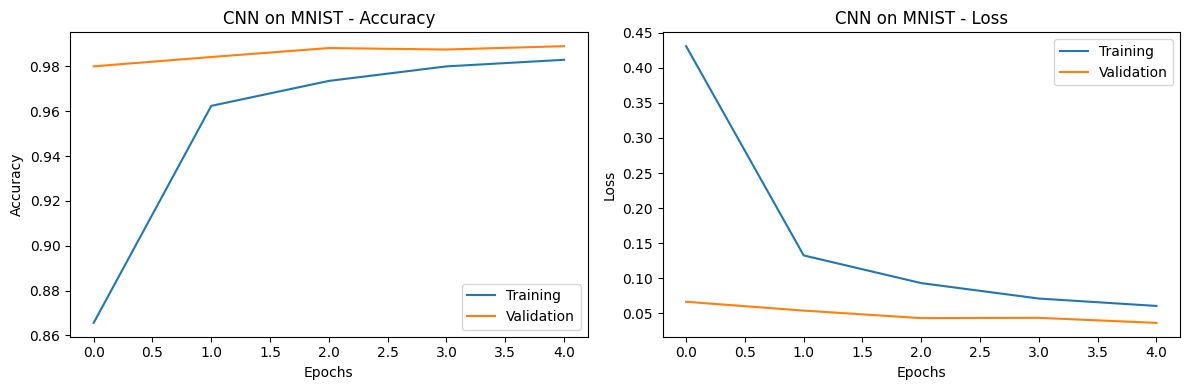


PART 2: CNN ON CIFAR-10 DATASET
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)

Training CNN on CIFAR-10...

Config 1: Basic CNN (32,64,64 filters)
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.3815 - loss: 1.8480 - val_accuracy: 0.4804 - val_loss: 1.4568
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5551 - loss: 1.2355 - val_accuracy: 0.6332 - val_loss: 1.0342
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6422 - loss: 1.0152 - val_accuracy: 0.6704 - val_loss: 0.9501
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6859 - loss: 0.8985 - val_accuracy: 0.6986 - val_loss: 0.8706
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7155 - loss: 0.8132 - val_accuracy: 0.7608 - val_loss: 0.6868

Config 2: Deeper CNN (64,128,256 filters)
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 34ms/step - accuracy: 0.4282 - loss: 1.7091 - val_accuracy: 0.5740 - val_loss: 1.1989
Epoch 2/5
704

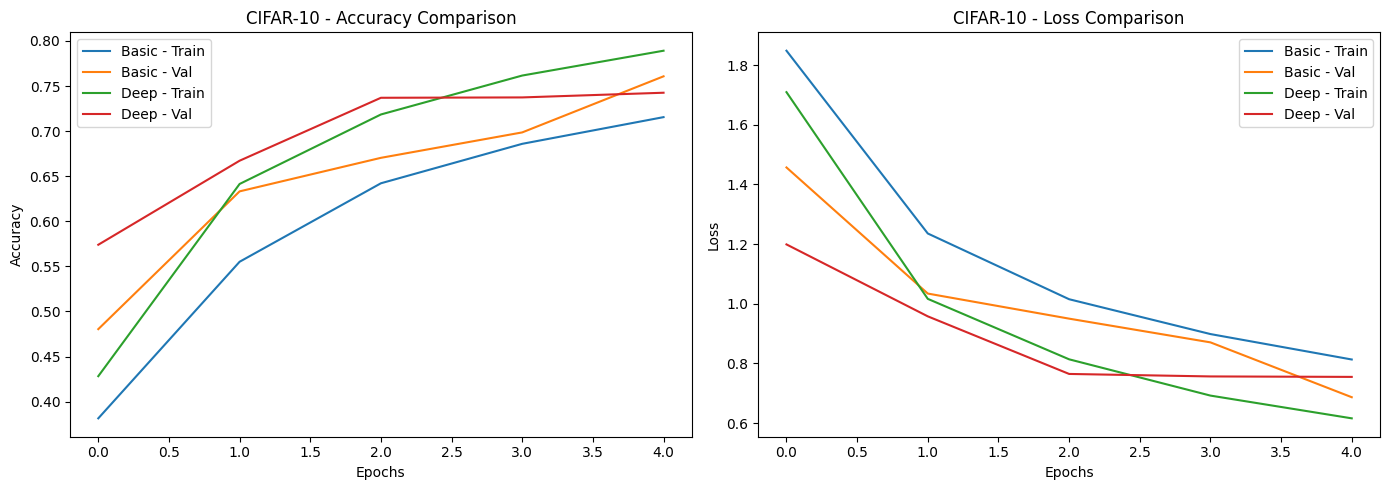


PART 3: CNN HYPERPARAMETER TUNING

Testing configuration 1: {'filters': [16, 32, 32], 'kernel_size': 3, 'dropout': 0.3, 'lr': 0.001}
Validation accuracy: 0.4280

Testing configuration 2: {'filters': [32, 64, 64], 'kernel_size': 3, 'dropout': 0.5, 'lr': 0.001}
Validation accuracy: 0.4310

Testing configuration 3: {'filters': [32, 64, 64], 'kernel_size': 5, 'dropout': 0.3, 'lr': 0.0001}
Validation accuracy: 0.3830

Testing configuration 4: {'filters': [64, 128, 128], 'kernel_size': 3, 'dropout': 0.5, 'lr': 0.0001}
Validation accuracy: 0.3960

BEST CONFIGURATION FOUND:
Configuration: 2
Parameters: {'filters': [32, 64, 64], 'kernel_size': 3, 'dropout': 0.5, 'lr': 0.001}
Validation Accuracy: 0.4310

PART 4: VISUALIZING CNN FEATURE MAPS


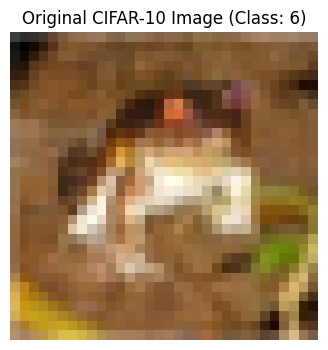


Available layers in model_basic:
  - conv1 (type: Conv2D)
  - bn1 (type: BatchNormalization)
  - conv2 (type: Conv2D)
  - bn2 (type: BatchNormalization)
  - pool1 (type: MaxPooling2D)
  - dropout1 (type: Dropout)
  - conv3 (type: Conv2D)
  - bn3 (type: BatchNormalization)
  - conv4 (type: Conv2D)
  - bn4 (type: BatchNormalization)
  - pool2 (type: MaxPooling2D)
  - dropout2 (type: Dropout)
  - conv5 (type: Conv2D)
  - bn5 (type: BatchNormalization)
  - conv6 (type: Conv2D)
  - bn6 (type: BatchNormalization)
  - pool3 (type: MaxPooling2D)
  - dropout3 (type: Dropout)
  - flatten (type: Flatten)
  - dense1 (type: Dense)
  - bn7 (type: BatchNormalization)
  - dropout4 (type: Dropout)
  - dense2 (type: Dense)
  - bn8 (type: BatchNormalization)
  - dropout5 (type: Dropout)
  - output (type: Dense)

Visualizing feature maps from first conv layer...
Error visualizing feature maps: The layer sequential_16 has never been called and thus has no defined input.

Visualizing feature maps from seco

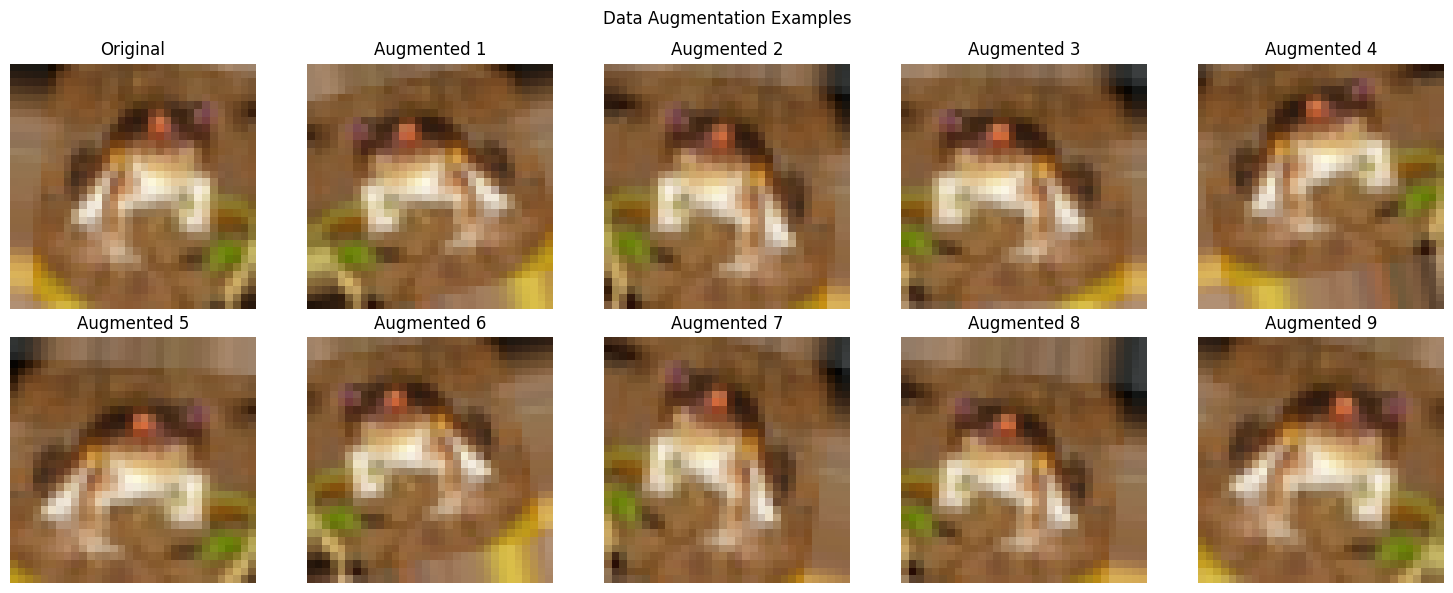

In [ ]:
"""
LAB: Deep Learning - CNN Implementations (Week 6) - CORRECTED
"""

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ============================================
# PART 1: CNN on MNIST Dataset
# ============================================
print("="*60)
print("PART 1: CNN ON MNIST DATASET")
print("="*60)

# Load MNIST
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = datasets.mnist.load_data()

# Preprocess
X_train_mnist = X_train_mnist.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test_mnist = X_test_mnist.reshape(-1, 28, 28, 1).astype('float32') / 255.0

y_train_mnist = to_categorical(y_train_mnist, 10)
y_test_mnist = to_categorical(y_test_mnist, 10)

print(f"Training data shape: {X_train_mnist.shape}")
print(f"Test data shape: {X_test_mnist.shape}")

def create_cnn_model():
    """Basic CNN architecture"""
    model = models.Sequential([
        # First convolutional block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv1'),
        layers.MaxPooling2D((2, 2), name='pool1'),

        # Second convolutional block
        layers.Conv2D(64, (3, 3), activation='relu', name='conv2'),
        layers.MaxPooling2D((2, 2), name='pool2'),

        # Third convolutional block
        layers.Conv2D(64, (3, 3), activation='relu', name='conv3'),

        # Dense layers
        layers.Flatten(name='flatten'),
        layers.Dense(64, activation='relu', name='dense1'),
        layers.Dropout(0.5, name='dropout'),
        layers.Dense(10, activation='softmax', name='output')
    ])

    return model

model_cnn_mnist = create_cnn_model()
model_cnn_mnist.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

model_cnn_mnist.summary()

# Train
history_mnist = model_cnn_mnist.fit(
    X_train_mnist, y_train_mnist,
    epochs=5,  # Reduced for faster execution
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# Evaluate
test_loss, test_acc = model_cnn_mnist.evaluate(X_test_mnist, y_test_mnist, verbose=0)
print(f"\nTest accuracy on MNIST: {test_acc:.4f}")

# Plot results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_mnist.history['accuracy'], label='Training')
plt.plot(history_mnist.history['val_accuracy'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN on MNIST - Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mnist.history['loss'], label='Training')
plt.plot(history_mnist.history['val_loss'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN on MNIST - Loss')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# PART 2: CNN on CIFAR-10 Dataset
# ============================================
print("\n" + "="*60)
print("PART 2: CNN ON CIFAR-10 DATASET")
print("="*60)

# Load CIFAR-10
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = datasets.cifar10.load_data()

# Preprocess
X_train_cifar = X_train_cifar.astype('float32') / 255.0
X_test_cifar = X_test_cifar.astype('float32') / 255.0

y_train_cifar = to_categorical(y_train_cifar, 10)
y_test_cifar = to_categorical(y_test_cifar, 10)

print(f"Training data shape: {X_train_cifar.shape}")
print(f"Test data shape: {X_test_cifar.shape}")

def create_improved_cnn(input_shape=(32, 32, 3), num_filters=[32, 64, 128]):
    """Improved CNN with configurable parameters and named layers"""
    model = models.Sequential()

    # First block
    model.add(layers.Conv2D(num_filters[0], (3, 3), activation='relu',
                           padding='same', input_shape=input_shape, name='conv1'))
    model.add(layers.BatchNormalization(name='bn1'))
    model.add(layers.Conv2D(num_filters[0], (3, 3), activation='relu',
                           padding='same', name='conv2'))
    model.add(layers.BatchNormalization(name='bn2'))
    model.add(layers.MaxPooling2D((2, 2), name='pool1'))
    model.add(layers.Dropout(0.25, name='dropout1'))

    # Second block
    model.add(layers.Conv2D(num_filters[1], (3, 3), activation='relu',
                           padding='same', name='conv3'))
    model.add(layers.BatchNormalization(name='bn3'))
    model.add(layers.Conv2D(num_filters[1], (3, 3), activation='relu',
                           padding='same', name='conv4'))
    model.add(layers.BatchNormalization(name='bn4'))
    model.add(layers.MaxPooling2D((2, 2), name='pool2'))
    model.add(layers.Dropout(0.25, name='dropout2'))

    # Third block
    model.add(layers.Conv2D(num_filters[2], (3, 3), activation='relu',
                           padding='same', name='conv5'))
    model.add(layers.BatchNormalization(name='bn5'))
    model.add(layers.Conv2D(num_filters[2], (3, 3), activation='relu',
                           padding='same', name='conv6'))
    model.add(layers.BatchNormalization(name='bn6'))
    model.add(layers.MaxPooling2D((2, 2), name='pool3'))
    model.add(layers.Dropout(0.25, name='dropout3'))

    # Dense layers
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(512, activation='relu', name='dense1'))
    model.add(layers.BatchNormalization(name='bn7'))
    model.add(layers.Dropout(0.5, name='dropout4'))
    model.add(layers.Dense(256, activation='relu', name='dense2'))
    model.add(layers.BatchNormalization(name='bn8'))
    model.add(layers.Dropout(0.5, name='dropout5'))
    model.add(layers.Dense(10, activation='softmax', name='output'))

    return model

# Train with different architectures
print("\nTraining CNN on CIFAR-10...")

# Configuration 1: Basic CNN
print("\nConfig 1: Basic CNN (32,64,64 filters)")
model_basic = create_improved_cnn(num_filters=[32, 64, 64])
model_basic.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

history_basic = model_basic.fit(
    X_train_cifar, y_train_cifar,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Configuration 2: Deeper CNN with more filters
print("\nConfig 2: Deeper CNN (64,128,256 filters)")
model_deep = create_improved_cnn(num_filters=[64, 128, 256])
model_deep.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

history_deep = model_deep.fit(
    X_train_cifar, y_train_cifar,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Plot comparison
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_basic.history['accuracy'], label='Basic - Train')
plt.plot(history_basic.history['val_accuracy'], label='Basic - Val')
plt.plot(history_deep.history['accuracy'], label='Deep - Train')
plt.plot(history_deep.history['val_accuracy'], label='Deep - Val')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CIFAR-10 - Accuracy Comparison')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_basic.history['loss'], label='Basic - Train')
plt.plot(history_basic.history['val_loss'], label='Basic - Val')
plt.plot(history_deep.history['loss'], label='Deep - Train')
plt.plot(history_deep.history['val_loss'], label='Deep - Val')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CIFAR-10 - Loss Comparison')
plt.legend()

plt.tight_layout()
plt.show()

# ============================================
# PART 3: CNN Hyperparameter Tuning
# ============================================
print("\n" + "="*60)
print("PART 3: CNN HYPERPARAMETER TUNING")
print("="*60)

def train_with_params(filters, kernel_size, dropout_rate, learning_rate):
    """Train CNN with specific hyperparameters"""
    model = models.Sequential([
        layers.Conv2D(filters[0], (kernel_size, kernel_size), activation='relu',
                     padding='same', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(filters[1], (kernel_size, kernel_size), activation='relu',
                     padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(filters[2], (kernel_size, kernel_size), activation='relu',
                     padding='same'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Use subset for quick experimentation
    X_subset = X_train_cifar[:5000]
    y_subset = y_train_cifar[:5000]

    history = model.fit(
        X_subset, y_subset,
        epochs=3,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    return max(history.history['val_accuracy'])

# Parameter combinations to try
param_combinations = [
    {'filters': [16, 32, 32], 'kernel_size': 3, 'dropout': 0.3, 'lr': 0.001},
    {'filters': [32, 64, 64], 'kernel_size': 3, 'dropout': 0.5, 'lr': 0.001},
    {'filters': [32, 64, 64], 'kernel_size': 5, 'dropout': 0.3, 'lr': 0.0001},
    {'filters': [64, 128, 128], 'kernel_size': 3, 'dropout': 0.5, 'lr': 0.0001},
]

results = []
for i, params in enumerate(param_combinations):
    print(f"\nTesting configuration {i+1}: {params}")
    val_acc = train_with_params(
        params['filters'],
        params['kernel_size'],
        params['dropout'],
        params['lr']
    )
    results.append({
        'config': i+1,
        'val_accuracy': val_acc,
        'params': params
    })
    print(f"Validation accuracy: {val_acc:.4f}")

# Find best configuration
best_config = max(results, key=lambda x: x['val_accuracy'])
print("\n" + "="*60)
print("BEST CONFIGURATION FOUND:")
print("="*60)
print(f"Configuration: {best_config['config']}")
print(f"Parameters: {best_config['params']}")
print(f"Validation Accuracy: {best_config['val_accuracy']:.4f}")

# ============================================
# PART 4: Visualize Feature Maps (CORRECTED)
# ============================================
print("\n" + "="*60)
print("PART 4: VISUALIZING CNN FEATURE MAPS")
print("="*60)

def visualize_feature_maps(model, image, layer_name):
    """Visualize feature maps from a specific layer"""
    try:
        # Check if layer exists
        if layer_name not in [layer.name for layer in model.layers]:
            print(f"Layer '{layer_name}' not found. Available layers:")
            for layer in model.layers:
                print(f"  - {layer.name}")
            return

        # Create a model that outputs feature maps
        layer_output = model.get_layer(layer_name).output
        feature_model = models.Model(inputs=model.input, outputs=layer_output)

        # Get feature maps
        feature_maps = feature_model.predict(image[np.newaxis, ...], verbose=0)

        # Plot feature maps
        n_features = min(16, feature_maps.shape[-1])
        fig, axes = plt.subplots(4, 4, figsize=(15, 15))
        for i in range(n_features):
            row, col = i // 4, i % 4
            axes[row, col].imshow(feature_maps[0, :, :, i], cmap='viridis')
            axes[row, col].axis('off')
            axes[row, col].set_title(f'Filter {i+1}')

        # Hide empty subplots
        for i in range(n_features, 16):
            row, col = i // 4, i % 4
            axes[row, col].axis('off')

        plt.suptitle(f'Feature Maps from Layer: {layer_name}')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error visualizing feature maps: {e}")

# Take a sample image from CIFAR-10
sample_image = X_train_cifar[0]
plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title('Original CIFAR-10 Image (Class: ' + str(y_train_cifar[0].argmax()) + ')')
plt.axis('off')
plt.show()

# Show available layers in the model
print("\nAvailable layers in model_basic:")
for layer in model_basic.layers:
    print(f"  - {layer.name} (type: {type(layer).__name__})")

# Visualize feature maps from first conv layer
print("\nVisualizing feature maps from first conv layer...")
visualize_feature_maps(model_basic, sample_image, 'conv1')

# Visualize feature maps from second conv layer
print("\nVisualizing feature maps from second conv layer...")
visualize_feature_maps(model_basic, sample_image, 'conv2')

# ============================================
# PART 5: Data Augmentation for CNN
# ============================================
print("\n" + "="*60)
print("PART 5: DATA AUGMENTATION FOR CNN")
print("="*60)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create data augmentation generator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Create a simple model for augmentation demonstration
model_aug = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_aug.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Train with data augmentation
print("\nTraining with data augmentation...")
history_aug = model_aug.fit(
    datagen.flow(X_train_cifar[:10000], y_train_cifar[:10000], batch_size=32),
    epochs=5,
    validation_data=(X_test_cifar[:2000], y_test_cifar[:2000]),
    verbose=1
)

# Visualize augmented images
print("\nVisualizing augmented images:")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    # Get a batch of augmented images
    for X_batch, y_batch in datagen.flow(X_train_cifar[:1], y_train_cifar[:1], batch_size=1):
        row, col = i // 5, i % 5
        axes[row, col].imshow(X_batch[0])
        axes[row, col].axis('off')
        if i == 0:
            axes[row, col].set_title('Original')
        else:
            axes[row, col].set_title(f'Augmented {i}')
        break
plt.suptitle('Data Augmentation Examples')
plt.tight_layout()
plt.show()

CNN ON FASHION MNIST
Training data: (60000, 28, 28, 1)
Test data: (10000, 28, 28, 1)


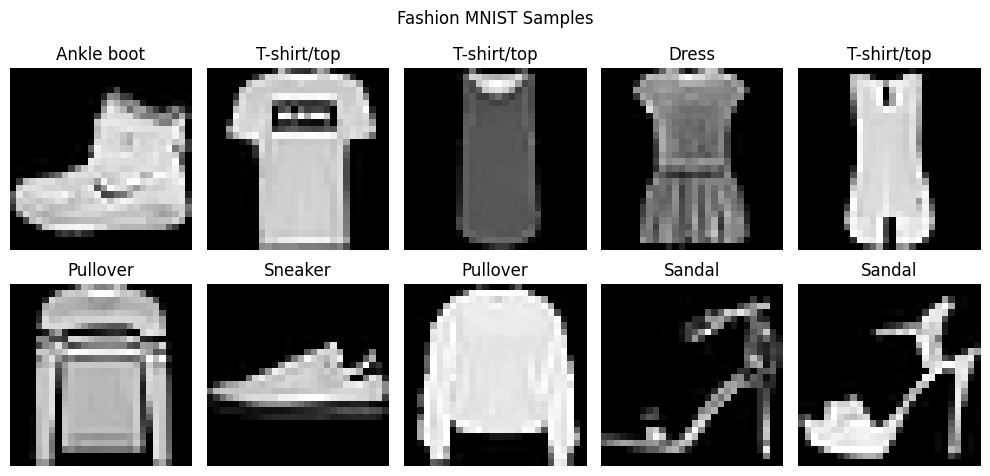


BUILDING SIMPLE CNN


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING CNN
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7719 - loss: 0.6284 - val_accuracy: 0.8355 - val_loss: 0.4324
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8588 - loss: 0.3895 - val_accuracy: 0.8715 - val_loss: 0.3557
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8776 - loss: 0.3363 - val_accuracy: 0.8833 - val_loss: 0.3269
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8915 - loss: 0.3018 - val_accuracy: 0.8833 - val_loss: 0.3204
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9016 - loss: 0.2747 - val_accuracy: 0.8902 - val_loss: 0.3019
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9063 - loss: 0.2574 - val_accuracy: 0.9012 - val_loss: 0.2708
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9119 - loss: 0.2420 - val_accuracy: 0.9012 - val_loss: 0.2765
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9171 - loss: 0.2260 - 

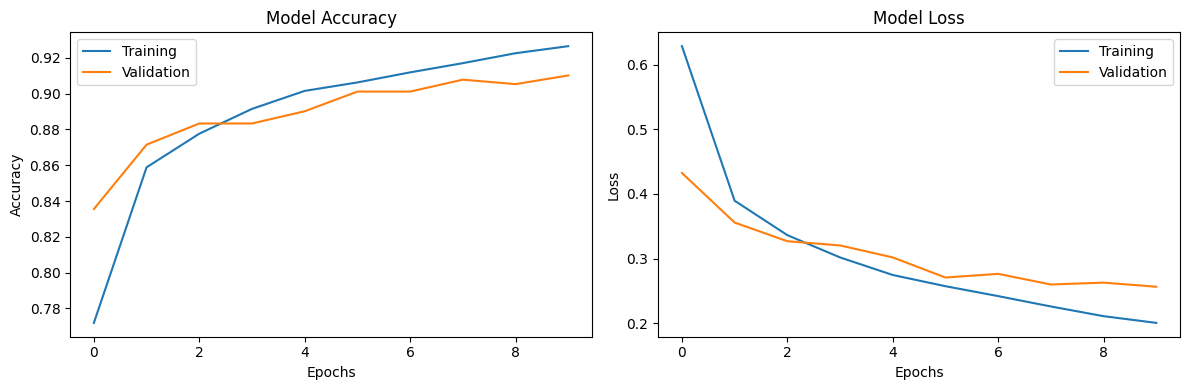


TESTING WITH SAMPLE IMAGES
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step


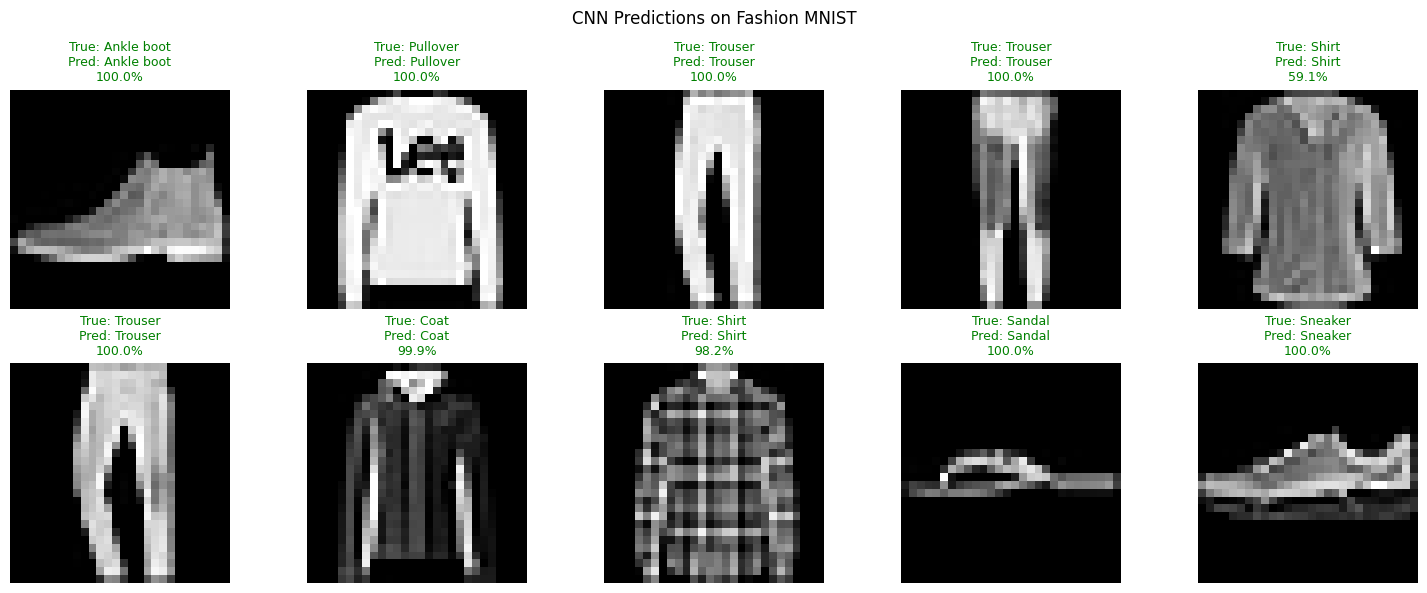


TRYING DIFFERENT LEARNING RATES

Training with learning rate: 0.1
Best validation accuracy: 0.1020

Training with learning rate: 0.01
Best validation accuracy: 0.8360

Training with learning rate: 0.001
Best validation accuracy: 0.8040

Training with learning rate: 0.0001
Best validation accuracy: 0.6960


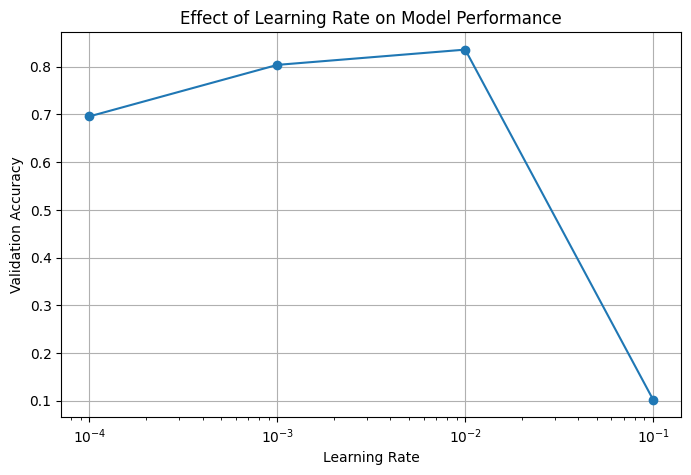


Best learning rate: 0.01


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, datasets

# ============================================
# 1. LOAD FASHION MNIST
# ============================================
print("="*60)
print("CNN ON FASHION MNIST")
print("="*60)

# Load data
(X_train, y_train), (X_test, y_test) = datasets.fashion_mnist.load_data()

# Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Preprocess
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"Training data: {X_train.shape}")
print(f"Test data: {X_test.shape}")

# Show samples
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')
plt.suptitle('Fashion MNIST Samples')
plt.tight_layout()
plt.show()

# ============================================
# 2. SIMPLE CNN MODEL
# ============================================
print("\n" + "="*60)
print("BUILDING SIMPLE CNN")
print("="*60)

model = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

# ============================================
# 3. TRAIN THE MODEL
# ============================================
print("\n" + "="*60)
print("TRAINING CNN")
print("="*60)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# ============================================
# 4. EVALUATE
# ============================================
print("\n" + "="*60)
print("EVALUATION")
print("="*60)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ============================================
# 5. TEST WITH SAMPLE
# ============================================
print("\n" + "="*60)
print("TESTING WITH SAMPLE IMAGES")
print("="*60)

# Make predictions
predictions = model.predict(X_test[:10])

# Show results
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')

    true_label = class_names[np.argmax(y_test[i])]
    pred_label = class_names[np.argmax(predictions[i])]
    confidence = np.max(predictions[i]) * 100

    color = 'green' if true_label == pred_label else 'red'
    plt.title(f'True: {true_label}\nPred: {pred_label}\n{confidence:.1f}%',
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('CNN Predictions on Fashion MNIST')
plt.tight_layout()
plt.show()

# ============================================
# 6. TRY DIFFERENT PARAMETERS
# ============================================
print("\n" + "="*60)
print("TRYING DIFFERENT LEARNING RATES")
print("="*60)

learning_rates = [0.1, 0.01, 0.001, 0.0001]
results = {}

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")

    # Create new model
    model_lr = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    # Use different optimizer with specific learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model_lr.compile(optimizer=optimizer,
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

    # Train briefly
    history_lr = model_lr.fit(
        X_train[:10000], y_train[:10000],  # Use subset for speed
        epochs=3,
        batch_size=128,
        validation_split=0.1,
        verbose=0
    )

    val_acc = max(history_lr.history['val_accuracy'])
    results[lr] = val_acc
    print(f"Best validation accuracy: {val_acc:.4f}")

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(list(results.keys()), list(results.values()), 'o-')
plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy')
plt.title('Effect of Learning Rate on Model Performance')
plt.grid(True)
plt.show()

print("\nBest learning rate:", max(results, key=results.get))

#Week 6

LeNet

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


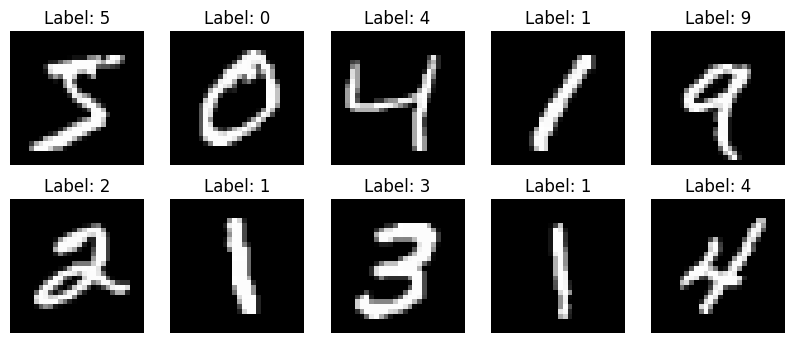

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8856 - loss: 0.3994 - val_accuracy: 0.9480 - val_loss: 0.1812
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9547 - loss: 0.1504 - val_accuracy: 0.9676 - val_loss: 0.1111
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9706 - loss: 0.0965 - val_accuracy: 0.9747 - val_loss: 0.0860
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9782 - loss: 0.0711 - val_accuracy: 0.9770 - val_loss: 0.0773
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9825 - loss: 0.0571 - val_accuracy: 0.9793 - val_loss: 0.0648
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9854 - loss: 0.0474 - val_accuracy: 0.9802 - val_loss: 0.0663
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9879 - loss: 0.0391 - val_accuracy: 0.9811 - val_loss: 0.0593
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9887 - loss: 0.0344 - val_accuracy: 0

In [1]:
import keras
import keras.utils
from keras import datasets, layers, models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

x_val = x_train[50000:]
y_val = y_train[50000:]

x_train_main = x_train_main / 255.0
x_val=x_val/255.0
x_test = x_test / 255.0

x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

LeNet5_Model=Sequential()
LeNet5_Model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)))
LeNet5_Model.add(AveragePooling2D((2, 2)))
LeNet5_Model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))
LeNet5_Model.add(AveragePooling2D((2, 2)))
LeNet5_Model.add(Flatten())
LeNet5_Model.add(Dense(120, activation='tanh'))
LeNet5_Model.add(Dense(84, activation='tanh'))
LeNet5_Model.add(Dense(10, activation='softmax'))

LeNet5_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

LeNet5_Model.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))

test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.7519 - loss: 0.6771 - val_accuracy: 0.7890 - val_loss: 0.5373
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8240 - loss: 0.4791 - val_accuracy: 0.8372 - val_loss: 0.4379
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8455 - loss: 0.4259 - val_accuracy: 0.8450 - val_loss: 0.4095
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8575 - loss: 0.3909 - val_accuracy: 0.8517 - val_loss: 0.3922
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8646 - loss: 0.3683 - val_accuracy: 0.8595 - val_loss: 0.3783
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8725 - loss: 0.3463 - val_accuracy: 0.8695 - val_loss: 0.3555
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s

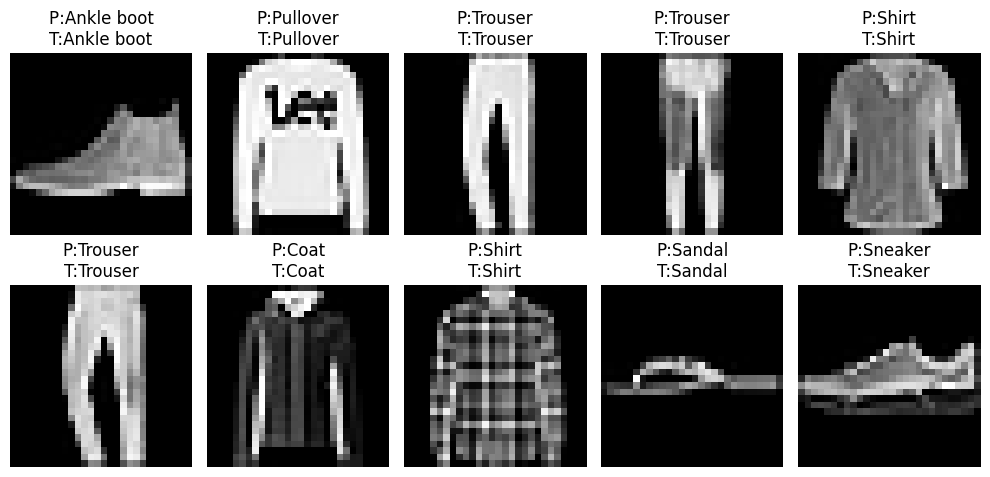

In [2]:
import keras
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD FASHION MNIST
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 2. PREPROCESS
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# 3. LENET-5 MODEL
model = Sequential([
    Conv2D(6, (5, 5), activation='tanh', input_shape=(28, 28, 1)),
    AveragePooling2D((2, 2)),
    Conv2D(16, (5, 5), activation='tanh'),
    AveragePooling2D((2, 2)),
    Flatten(),
    Dense(120, activation='tanh'),
    Dense(84, activation='tanh'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. TRAIN
model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

# 5. EVALUATE
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

# 6. VISUALIZE PREDICTIONS
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

    pred = np.argmax(model.predict(x_test[i].reshape(1, 28, 28, 1)))
    true = np.argmax(y_test[i])

    plt.title(f"P:{class_names[pred]}\nT:{class_names[true]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
import matplotlib.pyplot as plt

# 1. LOAD FASHION MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape (grayscale)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# MODEL DEFINITIONS

# LeNet-1 (very shallow)
def LeNet1():
    model = Sequential([
        Conv2D(4, (5, 5), activation='tanh', input_shape=(28, 28, 1)),
        AveragePooling2D((2, 2)),
        Flatten(),
        Dense(10, activation='softmax')
    ])
    return model

# LeNet-2
def LeNet2():
    model = Sequential([
        Conv2D(6, (5, 5), activation='tanh', input_shape=(28, 28, 1)),
        AveragePooling2D((2, 2)),
        Flatten(),
        Dense(50, activation='tanh'),
        Dense(10, activation='softmax')
    ])
    return model

# LeNet-3
def LeNet3():
    model = Sequential([
        Conv2D(6, (5, 5), activation='tanh', input_shape=(28, 28, 1)),
        AveragePooling2D((2, 2)),
        Conv2D(16, (5, 5), activation='tanh'),
        AveragePooling2D((2, 2)),
        Flatten(),
        Dense(84, activation='tanh'),
        Dense(10, activation='softmax')
    ])
    return model

# LeNet-4 (almost LeNet-5 but smaller FC)
def LeNet4():
    model = Sequential([
        Conv2D(6, (5, 5), activation='tanh', input_shape=(28, 28, 1)),
        AveragePooling2D((2, 2)),
        Conv2D(16, (5, 5), activation='tanh'),
        AveragePooling2D((2, 2)),
        Flatten(),
        Dense(120, activation='tanh'),
        Dense(10, activation='softmax')
    ])
    return model

# TRAIN & EVALUATE FUNCTION
def train_model(model_fn, name):
    print(f"\nTraining {name}...")

    model = model_fn()

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        epochs=5,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"{name} Test Accuracy: {acc:.4f}")

    return history, acc

# RUN ALL MODELS
results = {}

for model_fn, name in [
    (LeNet1, "LeNet-1"),
    (LeNet2, "LeNet-2"),
    (LeNet3, "LeNet-3"),
    (LeNet4, "LeNet-4")
]:
    history, acc = train_model(model_fn, name)
    results[name] = acc

# SUMMARY
print("\nFinal Results:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


Training LeNet-1...
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7147 - loss: 0.8140 - val_accuracy: 0.7947 - val_loss: 0.5646
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8071 - loss: 0.5316 - val_accuracy: 0.8210 - val_loss: 0.4826
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8322 - loss: 0.4691 - val_accuracy: 0.8368 - val_loss: 0.4392
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8454 - loss: 0.4372 - val_accuracy: 0.8452 - val_loss: 0.4241
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8526 - loss: 0.4167 - val_accuracy: 0.8532 - val_loss: 0.4113
LeNet-1 Test Accuracy: 0.8419

Training LeNet-2...
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.7856 - loss: 0.6197 - val_accuracy: 0.8318 - val_loss: 0.4623
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8451 - loss: 0.4348 - val_accuracy: 0.8490 - val_loss: 0.4055
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━

AlexNet

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,767,882 (94.48 MB)

 Trainable params: 24,767,882 (94.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 91s 9ms/step - accuracy: 0.1113 - loss: 2.3024 - val_accuracy: 0.1028 - val_loss: 2.3014
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 72s 9ms/step - accuracy: 0.1117 - loss: 2.3014 - val_accuracy: 0.1135 - val_loss: 2.3014
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - accuracy: 0.1122 - loss: 2.3015 - val_accuracy: 0.1135 - val_loss: 2.3013
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - accuracy: 0.1123 - loss: 2.3015 - val_accuracy: 0.1028 - val_loss: 2.3016
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 70s 9ms/step - accuracy: 0.1120 - loss: 2.3015 - val_accuracy: 0.1135 - val_loss: 2.3014
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1135 - loss: 2.3014
Test accuracy: 0.11349999904632568


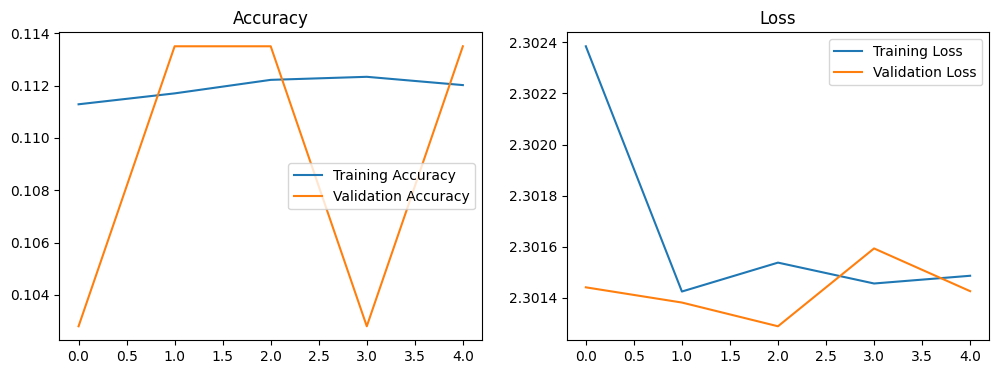

In [3]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
import matplotlib.pyplot as plt
import gc

# Clear previous session to free memory
keras.backend.clear_session()

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Preprocess images
x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

# Use 112x112 instead of 224x224 (reduces memory usage)
def process_image(image, label):
    image = tf.image.grayscale_to_rgb(image)  # Convert grayscale to RGB
    image = tf.image.resize(image, (112, 112))  # Resize to 112x112
    return image / 255.0, tf.one_hot(label, 10)

# Create dataset pipeline with smaller batch size (8 or 16)
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(process_image).batch(8).shuffle(1000).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(process_image).batch(8).prefetch(tf.data.AUTOTUNE)

# Enable mixed precision (reduces memory usage)
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Build AlexNet model (with 112x112 input shape)
model = Sequential()

# Layer 1: Convolution + MaxPooling
model.add(Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(112, 112, 3)))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Layer 2: Convolution + MaxPooling
model.add(Conv2D(256, (5, 5), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Layer 3-5: Convolution Layers
model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Flatten + Fully Connected Layers
model.add(Flatten())
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

# Compile model (use Adam optimizer and mixed precision)
model.compile(optimizer=keras.optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()

# Train model (with reduced batch size)
history = model.fit(train_dataset, epochs=5, validation_data=test_dataset)

# Evaluate model
test_loss, test_acc = model.evaluate(test_dataset)
print('Test accuracy:', test_acc)

# Clear memory after training
gc.collect()

# Plot Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,767,882 (94.48 MB)

 Trainable params: 24,767,882 (94.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 85s 9ms/step - accuracy: 0.7578 - loss: 0.6620 - val_accuracy: 0.8144 - val_loss: 0.5029
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 70s 9ms/step - accuracy: 0.8216 - loss: 0.5063 - val_accuracy: 0.8289 - val_loss: 0.4719
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - accuracy: 0.8300 - loss: 0.4765 - val_accuracy: 0.8157 - val_loss: 0.5002
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 86s 11ms/step - accuracy: 0.8304 - loss: 0.4779 - val_accuracy: 0.8351 - val_loss: 0.4555
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - accuracy: 0.8335 - loss: 0.4781 - val_accuracy: 0.8376 - val_loss: 0.4455
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8376 - loss: 0.4455
Test accuracy: 0.8375999927520752


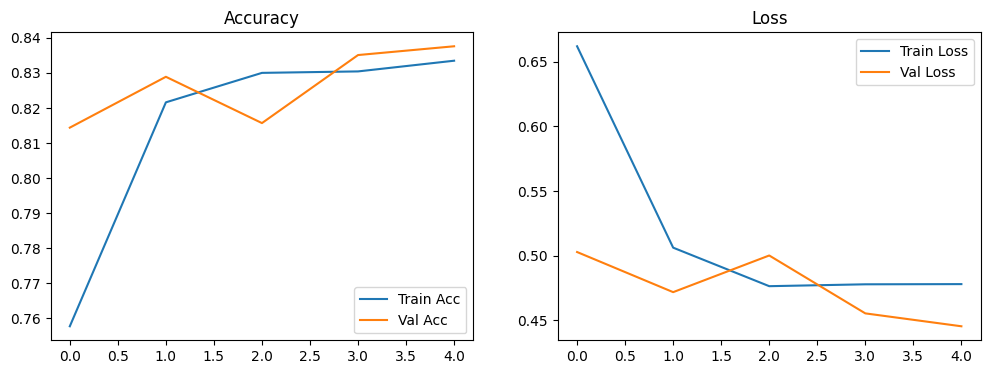

In [4]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
import matplotlib.pyplot as plt
import gc

# Clear session
keras.backend.clear_session()

# 1. LOAD FASHION MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Expand dims (grayscale → channel)
x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

# 2. PREPROCESS FUNCTION
def process_image(image, label):
    image = tf.image.grayscale_to_rgb(image)
    image = tf.image.resize(image, (112, 112))
    return image / 255.0, tf.one_hot(label, 10)

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(process_image).batch(8).shuffle(1000).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(process_image).batch(8).prefetch(tf.data.AUTOTUNE)

# 3. MIXED PRECISION
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# 4. ALEXNET MODEL
model = Sequential()

model.add(Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(112, 112, 3)))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

model.add(Conv2D(256, (5, 5), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

model.add(Flatten())
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

# 5. COMPILE
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 6. TRAIN
history = model.fit(train_dataset, epochs=5, validation_data=test_dataset)

# 7. EVALUATE
test_loss, test_acc = model.evaluate(test_dataset)
print('Test accuracy:', test_acc)

# 8. CLEAN MEMORY
gc.collect()

# 9. PLOT RESULTS
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

ZF-Net and VGG

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.datasets import mnist
import keras

# =========================
# 1. Load MNIST
# =========================
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize and reshape
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# 2. Define ZF-Net (small version)
# =========================
def ZFNet(input_shape=(28,28,1), num_classes=10):
    model = Sequential([
        Conv2D(32, (7, 7), strides=2, activation='relu', input_shape=input_shape, padding='same'),
        MaxPooling2D((3,3), strides=2),
        Conv2D(64, (5, 5), activation='relu', padding='same'),
        MaxPooling2D((3,3), strides=2),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((3,3), strides=2),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

# 3. Define VGGNet (small version)
def VGGNet(input_shape=(28,28,1), num_classes=10):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

# 4. Compile and train
def train_model(model_fn, name):
    print(f"\nTraining {name} on MNIST...")
    model = model_fn()
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1)
    loss, acc = model.evaluate(x_test, y_test)
    print(f"{name} Test Accuracy: {acc:.4f}")
    return model

zf_model = train_model(ZFNet, "ZF-Net")
vgg_model = train_model(VGGNet, "VGGNet")

1️⃣ ZF-Net (Custom) on MNIST

In [8]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1,28,28,1)/255.0
x_test = x_test.reshape(-1,28,28,1)/255.0

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Define ZF-Net (small)
def ZFNet(input_shape=(28,28,1), num_classes=10):
    model = Sequential([
        Conv2D(32,(7,7), strides=2, activation='relu', input_shape=input_shape, padding='same'),
        MaxPooling2D((3,3), strides=2),
        Conv2D(64,(5,5), activation='relu', padding='same'),
        MaxPooling2D((3,3), strides=2),
        Conv2D(128,(3,3), activation='relu', padding='same'),
        Conv2D(128,(3,3), activation='relu', padding='same'),
        Conv2D(64,(3,3), activation='relu', padding='same'),
        MaxPooling2D((3,3), strides=2),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

model = ZFNet()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Train
model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("ZF-Net Test Accuracy on MNIST:", acc)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 32)     │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 6, 6, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 2, 2, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 2, 2, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 0, 0, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 0)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 350,922 (1.34 MB)

 Trainable params: 350,922 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


ValueError: Exception encountered when calling MaxPooling2D.call().

[1mNegative dimension size caused by subtracting 3 from 2 for '{{node sequential_6_1/max_pooling2d_8_1/MaxPool2d}} = MaxPool[T=DT_HALF, data_format="NHWC", explicit_paddings=[], ksize=[1, 3, 3, 1], padding="VALID", strides=[1, 2, 2, 1]](sequential_6_1/conv2d_20_1/Relu)' with input shapes: [?,2,2,64].[0m

Arguments received by MaxPooling2D.call():
  • inputs=tf.Tensor(shape=(None, 2, 2, 64), dtype=float16)

2️⃣ Prebuilt ZF-like network on Fashion MNIST

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np

# Load Fashion MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Convert grayscale → RGB and resize
x_train = np.stack([x_train]*3, axis=-1)
x_test = np.stack([x_test]*3, axis=-1)
x_train = tf.image.resize(x_train,(32,32)).numpy()/255.0
x_test = tf.image.resize(x_test,(32,32)).numpy()/255.0

y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)

# Small ZF-like model
def ZFNet_like(input_shape=(32,32,3), num_classes=10):
    model = Sequential([
        Conv2D(32,(7,7), strides=2, activation='relu', input_shape=input_shape, padding='same'),
        MaxPooling2D((3,3), strides=2),
        Conv2D(64,(5,5), activation='relu', padding='same'),
        MaxPooling2D((3,3), strides=2),
        Conv2D(128,(3,3), activation='relu', padding='same'),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

model = ZFNet_like()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Train
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("ZF-like Test Accuracy on Fashion MNIST:", acc)

3️⃣ VGGNet (Custom small) on MNIST

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.applications import VGG16
import numpy as np

# Load Fashion MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Convert grayscale → RGB
x_train = np.stack([x_train]*3, axis=-1)
x_test = np.stack([x_test]*3, axis=-1)

# Resize to 224x224 for VGG16
x_train = tf.image.resize(x_train,(224,224)).numpy()/255.0
x_test = tf.image.resize(x_test,(224,224)).numpy()/255.0

y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)

# Prebuilt VGG16
vgg_model = VGG16(weights=None, input_shape=(224,224,3), classes=10)
vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
vgg_model.summary()

# Train
vgg_model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

# Evaluate
loss, acc = vgg_model.evaluate(x_test, y_test)
print("VGG16 Test Accuracy on Fashion MNIST:", acc)

4️⃣ Prebuilt VGG16 on Fashion MNIST

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.applications import VGG16
import numpy as np

# Load Fashion MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Convert grayscale → RGB
x_train = np.stack([x_train]*3, axis=-1)
x_test = np.stack([x_test]*3, axis=-1)

# Resize to 224x224 for VGG16
x_train = tf.image.resize(x_train,(224,224)).numpy()/255.0
x_test = tf.image.resize(x_test,(224,224)).numpy()/255.0

y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)

# Prebuilt VGG16
vgg_model = VGG16(weights=None, input_shape=(224,224,3), classes=10)
vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
vgg_model.summary()

# Train
vgg_model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

# Evaluate
loss, acc = vgg_model.evaluate(x_test, y_test)
print("VGG16 Test Accuracy on Fashion MNIST:", acc)